In [1]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image
from keras import __version__
from keras.applications import MobileNet
from keras.applications.mobilenet import preprocess_input
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam, SGD
from keras.models import Sequential
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import numpy as np


In [1]:
import psutil

# Get the current CPU affinity for your process
current_affinity = psutil.Process().cpu_affinity()

# Display the current CPU affinity
print("Current CPU Affinity:", current_affinity)

Current CPU Affinity: [0, 1, 2, 3, 4, 5, 6, 7]


In [3]:
dataset_folder = "D:\\DatasetNew" 

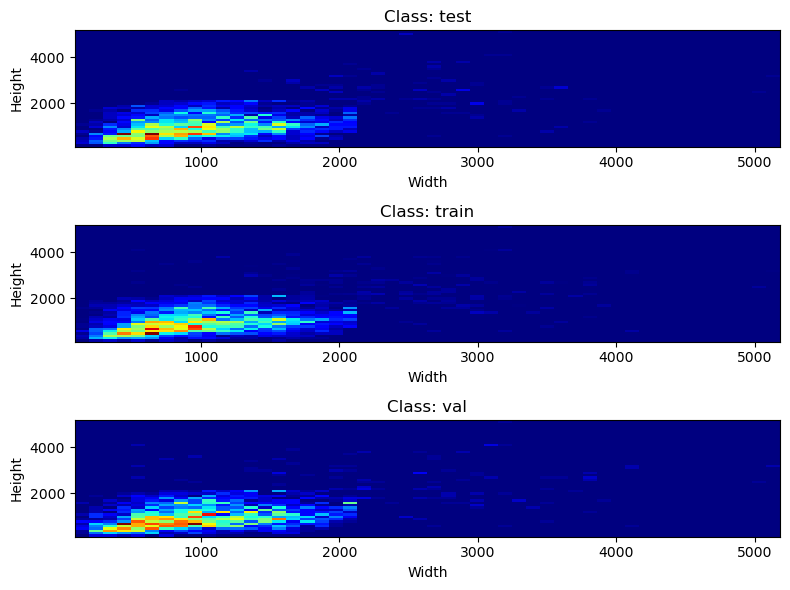

In [4]:
from PIL import Image
import os
import matplotlib.pyplot as plt

def plot_image_shapes(dataset_folder):
    class_shapes = {}

    for class_folder in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_folder)
        if os.path.isdir(class_path):
            class_shapes[class_folder] = []
            for snake_folder in os.listdir(class_path):
                snake_path = os.path.join(class_path, snake_folder)
                if os.path.isdir(snake_path):
                    for filename in os.listdir(snake_path):
                        if filename.endswith(('.png', '.jpg', '.jpeg')):
                            image_path = os.path.join(snake_path, filename)
                            with Image.open(image_path) as img:
                                width, height = img.size
                                class_shapes[class_folder].append((width, height))

    # Plotting
    fig, axes = plt.subplots(nrows=len(class_shapes), ncols=1, figsize=(8, 6))
    for i, (class_name, shapes) in enumerate(class_shapes.items()):
        axes[i].hist2d([w for w, _ in shapes], [h for _, h in shapes], bins=(50, 50), cmap=plt.cm.jet)
        axes[i].set_title(f"Class: {class_name}")
        axes[i].set_xlabel("Width")
        axes[i].set_ylabel("Height")

    plt.tight_layout()
    plt.show()


plot_image_shapes(dataset_folder)


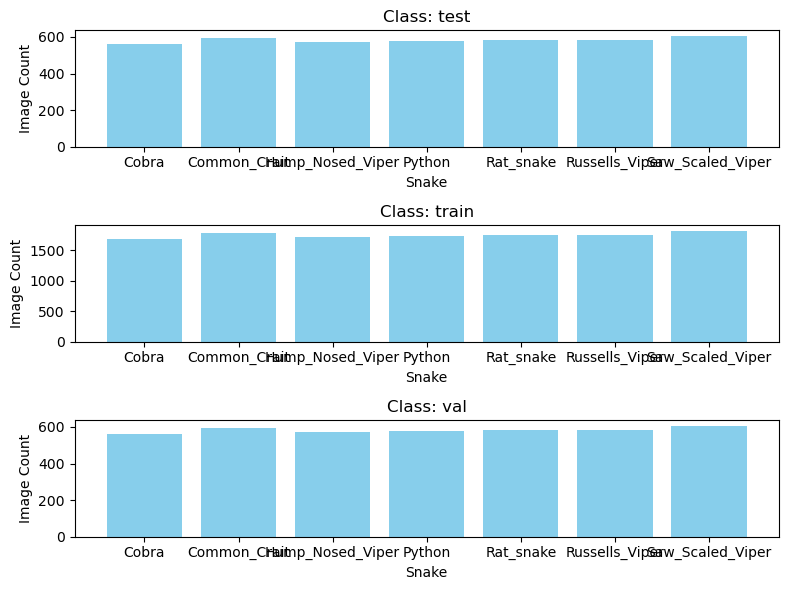

In [5]:
def plot_image_counts(dataset_folder):
    class_counts = {}

    for class_folder in os.listdir(dataset_folder):
        class_path = os.path.join(dataset_folder, class_folder)
        if os.path.isdir(class_path):
            class_counts[class_folder] = []
            for snake_folder in os.listdir(class_path):
                snake_path = os.path.join(class_path, snake_folder)
                if os.path.isdir(snake_path):
                    image_count = len([f for f in os.listdir(snake_path) if f.endswith(('.png', '.jpg', '.jpeg'))])
                    class_counts[class_folder].append((snake_folder, image_count))

    # Plotting
    fig, axes = plt.subplots(nrows=len(class_counts), ncols=1, figsize=(8, 6))
    for i, (class_name, counts) in enumerate(class_counts.items()):
        snakes, image_counts = zip(*counts)
        axes[i].bar(snakes, image_counts, color='skyblue')
        axes[i].set_title(f"Class: {class_name}")
        axes[i].set_xlabel("Snake")
        axes[i].set_ylabel("Image Count")

    plt.tight_layout()
    plt.show()

plot_image_counts(dataset_folder)

# Mobilenet Model

Found 12252 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.



Epoch 1/3


382/382 [==============================] - 763s 2s/step - loss: 0.7535 - accuracy: 0.7304 - val_loss: 0.3545 - val_accuracy: 0.8848
Epoch 2/3
382/382 [==============================] - 693s 2s/step - loss: 0.4283 - accuracy: 0.8493 - val_loss: 0.2788 - val_accuracy: 0.9043
Epoch 3/3
382/382 [==============================] - 688s 2s/step - loss: 0.3431 - accuracy: 0.8818 - val_loss: 0.2303 - val_accuracy: 0.9181
Epoch 1/3
382/382 [==============================] - 913s 2s/step - loss: 0.4711 - accuracy: 0.8341 - val_loss: 0.2263 - val_accuracy: 0.9225
Epoch 2/3
382/382 [==============================] - 955s 3s/step - loss: 0.3364 - accuracy: 0.8817 - val_loss: 0.1796 - val_accuracy: 0.9392
Epoch 3/3
382/382 [==============================] - 925s 2s/step - loss: 0.2979 - accuracy: 0.8932 - val_loss: 0.1620 - val_accuracy: 0.9441
INFO:tensorflow:Assets written to: mobilenet-ft.model\asse

INFO:tensorflow:Assets written to: mobilenet-ft.model\assets


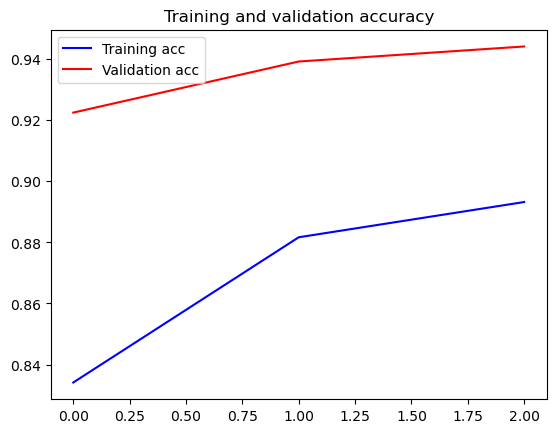

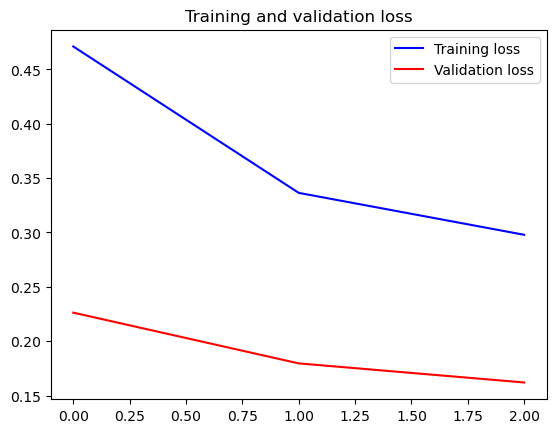

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizati  (None, 112, 112, 32)      128       
 on)                                                             
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D  (None, 112, 112, 32)      288       
 )                                                               
                                                                 
 conv_dw_1_bn (BatchNormali  (None, 112, 112, 32)      128   

 )                                                               
                                                                 
 conv_dw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_dw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_pw_8 (Conv2D)          (None, 14, 14, 512)       262144    
                                                                 
 conv_pw_8_bn (BatchNormali  (None, 14, 14, 512)       2048      
 zation)                                                         
                                                                 
 conv_pw_8_relu (ReLU)       (None, 14, 14, 512)       0         
                                                                 
 conv_dw_9 (DepthwiseConv2D  (None, 14, 14, 512)       4608      
 )        

In [6]:
from keras.applications.mobilenet import MobileNet, preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dropout

IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_MN_LAYERS_TO_FREEZE = 20
train_dir = "D:\\DatasetNew\\train"
val_dir = "D:\\DatasetNew\\val"
test_dir = "D:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

def add_new_last_layer_mobilenet(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)  # Add dropout layer
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_mobilenet(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_mobilenet(model):
    for layer in model.layers[:NB_MN_LAYERS_TO_FREEZE]:
        layer.trainable = False
    for layer in model.layers[NB_MN_LAYERS_TO_FREEZE:]:
        layer.trainable = True
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

def train_mobilenet(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenet-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
        # Filling strategy for rotated images
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_mobilenet(base_model, nb_classes)

    setup_to_transfer_learn_mobilenet(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    setup_to_finetune_mobilenet(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the MobileNet model and get the trained model
trained_mobilenet_model = train_mobilenet(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS,
batch_size=BAT_SIZE, output_model_file="mobilenet-ft.model", plot=True)

# Display the model summary
trained_mobilenet_model.summary()

# resnet50v2

In [1]:
import os
import glob
import matplotlib.pyplot as plt
from keras.applications import ResNet50V2
from keras.applications.resnet_v2 import preprocess_input, decode_predictions
from keras.models import Model
from keras.layers import Dense, GlobalAveragePooling2D, Dropout
from keras.optimizers import SGD
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from sklearn.model_selection import train_test_split

Found 12112 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.
Epoch 1/3
378/378 [==============================] - 1042s 3s/step - loss: 0.7020 - accuracy: 0.7470 - val_loss: 0.3356 - val_accuracy: 0.8819
Epoch 2/3
378/378 [==============================] - 1059s 3s/step - loss: 0.4416 - accuracy: 0.8370 - val_loss: 0.2900 - val_accuracy: 0.8925
Epoch 3/3
378/378 [==============================] - 1045s 3s/step - loss: 0.3699 - accuracy: 0.8632 - val_loss: 0.2668 - val_accuracy: 0.9092
Epoch 1/3
378/378 [==============================] - 1170s 3s/step - loss: 0.5151 - accuracy: 0.8188 - val_loss: 0.2949 - val_accuracy: 0.8989
Epoch 2/3
378/378 [==============================] - 1170s 3s/step - loss: 0.3903 - accuracy: 0.8661 - val_loss: 0.2359 - val_accuracy: 0.9205
Epoch 3/3
378/378 [==============================] - 1195s 3s/step - loss: 0.3289 - accuracy: 0.8878 - val_loss: 0.2064 - val_accuracy: 0.9321
INFO:tensorflow:Assets written to: resnet50v2-ft.model\as

INFO:tensorflow:Assets written to: resnet50v2-ft.model\assets


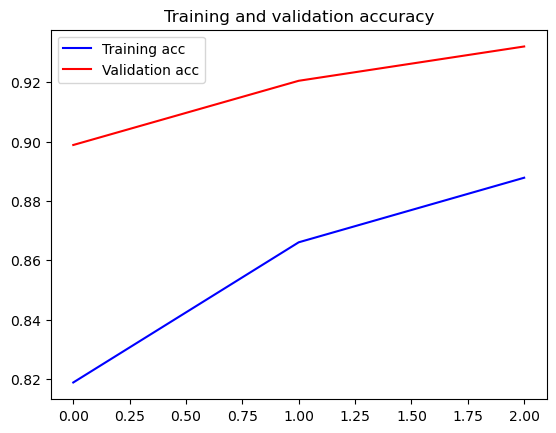

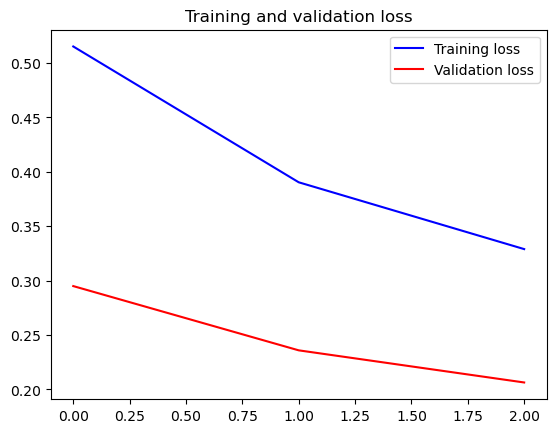

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_conv[0][0]']          
                                                                                            

 tchNormalization)                                                                                
                                                                                                  
 conv2_block3_preact_relu (  (None, 56, 56, 256)          0         ['conv2_block3_preact_bn[0][0]
 Activation)                                                        ']                            
                                                                                                  
 conv2_block3_1_conv (Conv2  (None, 56, 56, 64)           16384     ['conv2_block3_preact_relu[0][
 D)                                                                 0]']                          
                                                                                                  
 conv2_block3_1_bn (BatchNo  (None, 56, 56, 64)           256       ['conv2_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
          

 conv3_block2_1_relu (Activ  (None, 28, 28, 128)          0         ['conv3_block2_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv3_block2_2_pad (ZeroPa  (None, 30, 30, 128)          0         ['conv3_block2_1_relu[0][0]'] 
 dding2D)                                                                                         
                                                                                                  
 conv3_block2_2_conv (Conv2  (None, 28, 28, 128)          147456    ['conv3_block2_2_pad[0][0]']  
 D)                                                                                               
                                                                                                  
 conv3_block2_2_bn (BatchNo  (None, 28, 28, 128)          512       ['conv3_block2_2_conv[0][0]'] 
 rmalizati

                                                                                                  
 conv3_block4_3_conv (Conv2  (None, 14, 14, 512)          66048     ['conv3_block4_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv3_block4_out (Add)      (None, 14, 14, 512)          0         ['max_pooling2d_7[0][0]',     
                                                                     'conv3_block4_3_conv[0][0]'] 
                                                                                                  
 conv4_block1_preact_bn (Ba  (None, 14, 14, 512)          2048      ['conv3_block4_out[0][0]']    
 tchNormalization)                                                                                
                                                                                                  
 conv4_blo

 D)                                                                 0]']                          
                                                                                                  
 conv4_block3_1_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block3_1_relu (Activ  (None, 14, 14, 256)          0         ['conv4_block3_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block3_2_pad (ZeroPa  (None, 16, 16, 256)          0         ['conv4_block3_1_relu[0][0]'] 
 dding2D)                                                                                         
          

 conv4_block5_2_relu (Activ  (None, 14, 14, 256)          0         ['conv4_block5_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block5_3_conv (Conv2  (None, 14, 14, 1024)         263168    ['conv4_block5_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block5_out (Add)      (None, 14, 14, 1024)         0         ['conv4_block4_out[0][0]',    
                                                                     'conv4_block5_3_conv[0][0]'] 
                                                                                                  
 conv4_block6_preact_bn (Ba  (None, 14, 14, 1024)         4096      ['conv4_block5_out[0][0]']    
 tchNormal

                                                                                                  
 conv5_block2_preact_relu (  (None, 7, 7, 2048)           0         ['conv5_block2_preact_bn[0][0]
 Activation)                                                        ']                            
                                                                                                  
 conv5_block2_1_conv (Conv2  (None, 7, 7, 512)            1048576   ['conv5_block2_preact_relu[0][
 D)                                                                 0]']                          
                                                                                                  
 conv5_block2_1_bn (BatchNo  (None, 7, 7, 512)            2048      ['conv5_block2_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_blo

In [7]:


IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_RES_BLOCKS_TO_FREEZE = 4  # Number of blocks in stage 4
train_dir = "D:\\DatasetNew\\train"
val_dir = "D:\\DatasetNew\\val"
test_dir = "D:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count


def add_new_last_layer_resnet50v2(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)  # Add dropout layer
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_resnet50v2(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_resnet50v2(model):
    # Find the index of the last convolutional block in stage 4
    for i, layer in enumerate(model.layers):
        if 'conv4_block' in layer.name:
            last_conv_block_index = i
    
    # Freeze layers up to the last convolutional block in stage 4
    for layer in model.layers[:last_conv_block_index + 1]:
        layer.trainable = False
    
    # Fine-tune layers from the last convolutional block in stage 4 onwards
    for layer in model.layers[last_conv_block_index + 1:]:
        layer.trainable = True

    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

    
def train_resnet50v2(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="resnet50v2-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_resnet50v2(base_model, nb_classes)

    setup_to_transfer_learn_resnet50v2(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
    )

    setup_to_finetune_resnet50v2(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the ResNet50V2 model and get the trained model
trained_resnet50v2_model = train_resnet50v2(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="resnet50v2-ft.model", plot=True)

# Display the model summary
trained_resnet50v2_model.summary()


# InceptionV3

Found 12112 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.
Epoch 1/3
378/378 [==============================] - 928s 2s/step - loss: 0.8842 - accuracy: 0.6768 - val_loss: 0.5235 - val_accuracy: 0.8191
Epoch 2/3
378/378 [==============================] - 884s 2s/step - loss: 0.6415 - accuracy: 0.7617 - val_loss: 0.4913 - val_accuracy: 0.8204
Epoch 3/3
378/378 [==============================] - 853s 2s/step - loss: 0.6030 - accuracy: 0.7794 - val_loss: 0.4293 - val_accuracy: 0.8410
Epoch 1/3
378/378 [==============================] - 1013s 3s/step - loss: 0.8546 - accuracy: 0.7060 - val_loss: 0.4933 - val_accuracy: 0.8369
Epoch 2/3
378/378 [==============================] - 1006s 3s/step - loss: 0.5841 - accuracy: 0.8055 - val_loss: 0.3783 - val_accuracy: 0.8743
Epoch 3/3
378/378 [==============================] - 1012s 3s/step - loss: 0.4798 - accuracy: 0.8413 - val_loss: 0.2958 - val_accuracy: 0.8996
INFO:tensorflow:Assets written to: inceptionv3-ft.model\asse

INFO:tensorflow:Assets written to: inceptionv3-ft.model\assets


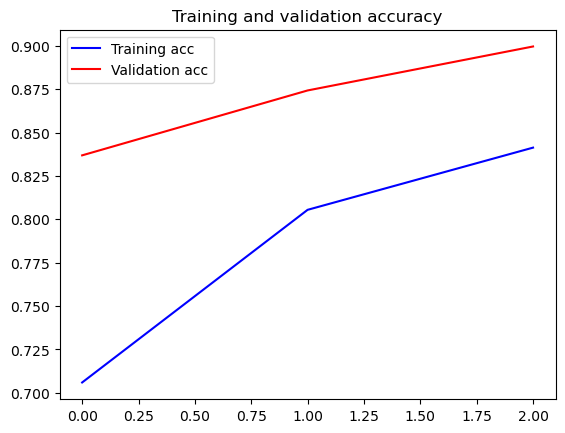

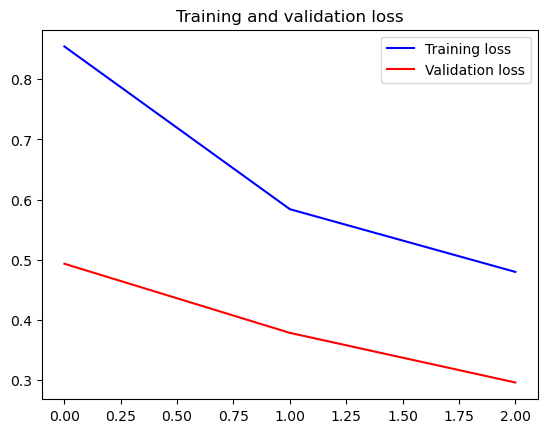

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 111, 111, 32)         864       ['input_4[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 111, 111, 32)         96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 111, 111, 32)         0         ['batch_normalization[0]

 conv2d_11 (Conv2D)          (None, 25, 25, 32)           6144      ['average_pooling2d[0][0]']   
                                                                                                  
 batch_normalization_5 (Bat  (None, 25, 25, 64)           192       ['conv2d_5[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 batch_normalization_7 (Bat  (None, 25, 25, 64)           192       ['conv2d_7[0][0]']            
 chNormalization)                                                                                 
                                                                                                  
 batch_normalization_10 (Ba  (None, 25, 25, 96)           288       ['conv2d_10[0][0]']           
 tchNormalization)                                                                                
          

                                                                                                  
 activation_17 (Activation)  (None, 25, 25, 96)           0         ['batch_normalization_17[0][0]
                                                                    ']                            
                                                                                                  
 activation_18 (Activation)  (None, 25, 25, 64)           0         ['batch_normalization_18[0][0]
                                                                    ']                            
                                                                                                  
 mixed1 (Concatenate)        (None, 25, 25, 288)          0         ['activation_12[0][0]',       
                                                                     'activation_14[0][0]',       
                                                                     'activation_17[0][0]',       
          

                                                                                                  
 conv2d_28 (Conv2D)          (None, 25, 25, 96)           55296     ['activation_27[0][0]']       
                                                                                                  
 batch_normalization_28 (Ba  (None, 25, 25, 96)           288       ['conv2d_28[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_28 (Activation)  (None, 25, 25, 96)           0         ['batch_normalization_28[0][0]
                                                                    ']                            
                                                                                                  
 conv2d_26 (Conv2D)          (None, 12, 12, 384)          995328    ['mixed2[0][0]']              
          

 conv2d_30 (Conv2D)          (None, 12, 12, 192)          147456    ['mixed3[0][0]']              
                                                                                                  
 conv2d_33 (Conv2D)          (None, 12, 12, 192)          172032    ['activation_32[0][0]']       
                                                                                                  
 conv2d_38 (Conv2D)          (None, 12, 12, 192)          172032    ['activation_37[0][0]']       
                                                                                                  
 conv2d_39 (Conv2D)          (None, 12, 12, 192)          147456    ['average_pooling2d_3[0][0]'] 
                                                                                                  
 batch_normalization_30 (Ba  (None, 12, 12, 192)          576       ['conv2d_30[0][0]']           
 tchNormalization)                                                                                
          

...

                                                                                                  
 activation_52 (Activation)  (None, 12, 12, 160)          0         ['batch_normalization_52[0][0]
                                                                    ']                            
                                                                                                  
 activation_57 (Activation)  (None, 12, 12, 160)          0         ['batch_normalization_57[0][0]
                                                                    ']                            
                                                                                                  
 average_pooling2d_5 (Avera  (None, 12, 12, 768)          0         ['mixed5[0][0]']              
 gePooling2D)                                                                                     
                                                                                                  
 conv2d_50

 batch_normalization_62 (Ba  (None, 12, 12, 192)          576       ['conv2d_62[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 batch_normalization_67 (Ba  (None, 12, 12, 192)          576       ['conv2d_67[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_62 (Activation)  (None, 12, 12, 192)          0         ['batch_normalization_62[0][0]
                                                                    ']                            
                                                                                                  
 activation_67 (Activation)  (None, 12, 12, 192)          0         ['batch_normalization_67[0][0]
          

                                                                                                  
 conv2d_71 (Conv2D)          (None, 5, 5, 320)            552960    ['activation_70[0][0]']       
                                                                                                  
 conv2d_75 (Conv2D)          (None, 5, 5, 192)            331776    ['activation_74[0][0]']       
                                                                                                  
 batch_normalization_71 (Ba  (None, 5, 5, 320)            960       ['conv2d_71[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 batch_normalization_75 (Ba  (None, 5, 5, 192)            576       ['conv2d_75[0][0]']           
 tchNormalization)                                                                                
          

                                                                                                  
 activation_82 (Activation)  (None, 5, 5, 384)            0         ['batch_normalization_82[0][0]
                                                                    ']                            
                                                                                                  
 activation_83 (Activation)  (None, 5, 5, 384)            0         ['batch_normalization_83[0][0]
                                                                    ']                            
                                                                                                  
 batch_normalization_84 (Ba  (None, 5, 5, 192)            576       ['conv2d_84[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activatio

                                                                                                  
 activation_88 (Activation)  (None, 5, 5, 384)            0         ['batch_normalization_88[0][0]
                                                                    ']                            
                                                                                                  
 activation_91 (Activation)  (None, 5, 5, 384)            0         ['batch_normalization_91[0][0]
                                                                    ']                            
                                                                                                  
 activation_92 (Activation)  (None, 5, 5, 384)            0         ['batch_normalization_92[0][0]
                                                                    ']                            
                                                                                                  
 batch_nor

In [8]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.applications.inception_v3 import preprocess_input
import os
import glob
import matplotlib.pyplot as plt

IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_IV3_LAYERS_TO_FREEZE = 172  # The exact number may vary, this is an estimate
train_dir = "C:\\DatasetNew\\train"
val_dir = "C:\\DatasetNew\\val"
test_dir = "C:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

def add_new_last_layer_inceptionv3(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_inceptionv3(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_inceptionv3(model):
    for layer in model.layers[:NB_IV3_LAYERS_TO_FREEZE]:
        layer.trainable = False
    for layer in model.layers[NB_IV3_LAYERS_TO_FREEZE:]:
        layer.trainable = True
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

def train_inceptionv3(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="inceptionv3-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_inceptionv3(base_model, nb_classes)

    setup_to_transfer_learn_inceptionv3(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
    )

    setup_to_finetune_inceptionv3(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the InceptionV3 model and get the trained model
trained_inceptionv3_model = train_inceptionv3(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="inceptionv3-ft.model", plot=True)

# Display the model summary
trained_inceptionv3_model.summary()


# Xception model


Found 12112 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.


83683744/83683744 [==============================] - 361s 4us/step

Epoch 1/3


378/378 [==============================] - 1059s 3s/step - loss: 0.6992 - accuracy: 0.7401 - val_loss: 0.4178 - val_accuracy: 0.8536
Epoch 2/3
378/378 [==============================] - 1076s 3s/step - loss: 0.4613 - accuracy: 0.8336 - val_loss: 0.3330 - val_accuracy: 0.8802
Epoch 3/3
378/378 [==============================] - 1198s 3s/step - loss: 0.4035 - accuracy: 0.8546 - val_loss: 0.2889 - val_accuracy: 0.8964
Epoch 1/3
378/378 [==============================] - 3529s 9s/step - loss: 0.7657 - accuracy: 0.7396 - val_loss: 0.4616 - val_accuracy: 0.8484
Epoch 2/3
378/378 [==============================] - 3628s 10s/step - loss: 0.5491 - accuracy: 0.8142 - val_loss: 0.3900 - val_accuracy: 0.8733
Epoch 3/3
378/378 [==============================] - 3321s 9s/step - loss: 0.4561 - accuracy: 0.8447 - val_loss: 0.3228 - val_

INFO:tensorflow:Assets written to: xception-ft.model\assets


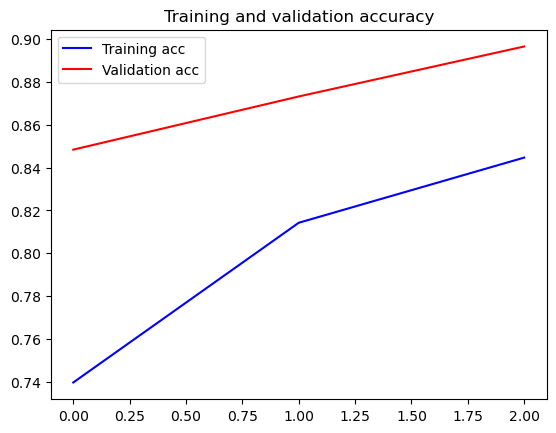

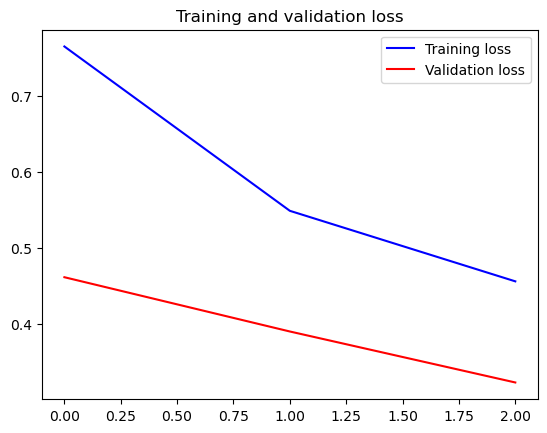

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 block1_conv1 (Conv2D)       (None, 111, 111, 32)         864       ['input_1[0][0]']             
                                                                                                  
 block1_conv1_bn (BatchNorm  (None, 111, 111, 32)         128       ['block1_conv1[0][0]']        
 alization)                                                                                       
                                                                                                  
 block1_conv1_act (Activati  (None, 111, 111, 32)         0         ['block1_conv1_bn[0][0]'] 

                                                                                                  
 block4_sepconv2_act (Activ  (None, 28, 28, 728)          0         ['block4_sepconv1_bn[0][0]']  
 ation)                                                                                           
                                                                                                  
 block4_sepconv2 (Separable  (None, 28, 28, 728)          536536    ['block4_sepconv2_act[0][0]'] 
 Conv2D)                                                                                          
                                                                                                  
 block4_sepconv2_bn (BatchN  (None, 28, 28, 728)          2912      ['block4_sepconv2[0][0]']     
 ormalization)                                                                                    
                                                                                                  
 conv2d_2 

                                                                                                  
 block7_sepconv1 (Separable  (None, 14, 14, 728)          536536    ['block7_sepconv1_act[0][0]'] 
 Conv2D)                                                                                          
                                                                                                  
 block7_sepconv1_bn (BatchN  (None, 14, 14, 728)          2912      ['block7_sepconv1[0][0]']     
 ormalization)                                                                                    
                                                                                                  
 block7_sepconv2_act (Activ  (None, 14, 14, 728)          0         ['block7_sepconv1_bn[0][0]']  
 ation)                                                                                           
                                                                                                  
 block7_se

 ormalization)                                                                                    
                                                                                                  
 add_7 (Add)                 (None, 14, 14, 728)          0         ['block9_sepconv3_bn[0][0]',  
                                                                     'add_6[0][0]']               
                                                                                                  
 block10_sepconv1_act (Acti  (None, 14, 14, 728)          0         ['add_7[0][0]']               
 vation)                                                                                          
                                                                                                  
 block10_sepconv1 (Separabl  (None, 14, 14, 728)          536536    ['block10_sepconv1_act[0][0]']
 eConv2D)                                                                                         
          

 block12_sepconv3_act (Acti  (None, 14, 14, 728)          0         ['block12_sepconv2_bn[0][0]'] 
 vation)                                                                                          
                                                                                                  
 block12_sepconv3 (Separabl  (None, 14, 14, 728)          536536    ['block12_sepconv3_act[0][0]']
 eConv2D)                                                                                         
                                                                                                  
 block12_sepconv3_bn (Batch  (None, 14, 14, 728)          2912      ['block12_sepconv3[0][0]']    
 Normalization)                                                                                   
                                                                                                  
 add_10 (Add)                (None, 14, 14, 728)          0         ['block12_sepconv3_bn[0][0]', 
          

In [1]:
import os
import glob
from keras.applications.xception import Xception, preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model
from keras.optimizers import SGD
import matplotlib.pyplot as plt

IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_XC_LAYERS_TO_FREEZE = 20  # Adjust this parameter
train_dir = "C:\\DatasetNew\\train"
val_dir = "C:\\DatasetNew\\val"
test_dir = "C:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

def add_new_last_layer_xception(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)  # Add dropout layer
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_xception(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_xception(model):
    for layer in model.layers[:NB_XC_LAYERS_TO_FREEZE]:
        layer.trainable = False
    for layer in model.layers[NB_XC_LAYERS_TO_FREEZE:]:
        layer.trainable = True
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def train_xception(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="xception-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = Xception(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_xception(base_model, nb_classes)

    setup_to_transfer_learn_xception(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    setup_to_finetune_xception(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    model.save(output_model_file)

    if plot:
        acc = history_ft.history['accuracy']
        val_acc = history_ft.history['val_accuracy']
        loss = history_ft.history['loss']
        val_loss = history_ft.history['val_loss']
        epochs = range(len(acc))

        plt.plot(epochs, acc, 'b', label='Training acc')
        plt.plot(epochs, val_acc, 'r', label='Validation acc')
        plt.title('Training and validation accuracy')
        plt.legend()

        plt.figure()

        plt.plot(epochs, loss, 'b', label='Training loss')
        plt.plot(epochs, val_loss, 'r', label='Validation loss')
        plt.title('Training and validation loss')
        plt.legend()

        plt.show()

    return model

# Train the Xception model and get the trained model
trained_xception_model = train_xception(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="xception-ft.model", plot=True)

# Display the model summary
trained_xception_model.summary()


# mobilenetv2 model


Found 12112 images belonging to 7 classes.
Found 4084 images belonging to 7 classes.



Epoch 1/3


378/378 [==============================] - 554s 1s/step - loss: 0.6967 - accuracy: 0.7499 - val_loss: 0.3777 - val_accuracy: 0.8637
Epoch 2/3
378/378 [==============================] - 541s 1s/step - loss: 0.4209 - accuracy: 0.8484 - val_loss: 0.3041 - val_accuracy: 0.8888
Epoch 3/3
378/378 [==============================] - 550s 1s/step - loss: 0.3600 - accuracy: 0.8713 - val_loss: 0.2613 - val_accuracy: 0.9067
Epoch 1/3
378/378 [==============================] - 979s 3s/step - loss: 0.5750 - accuracy: 0.7999 - val_loss: 0.2500 - val_accuracy: 0.9077
Epoch 2/3
378/378 [==============================] - 921s 2s/step - loss: 0.3536 - accuracy: 0.8781 - val_loss: 0.1903 - val_accuracy: 0.9313
Epoch 3/3
378/378 [==============================] - 914s 2s/step - loss: 0.2921 - accuracy: 0.8988 - val_loss: 0.1524 - val_accuracy: 0.9427
INFO:tensorflow:Assets written to: mobilenetv2-ft.model\a

INFO:tensorflow:Assets written to: mobilenetv2-ft.model\assets


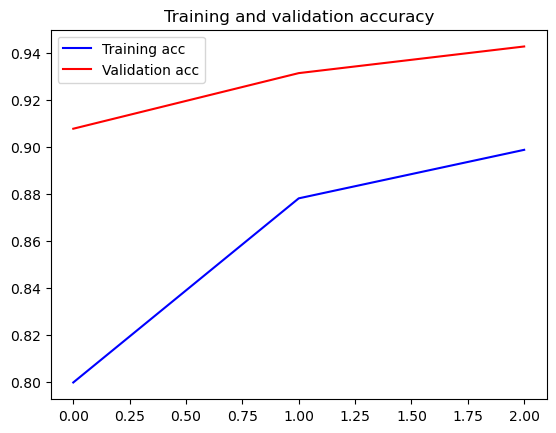

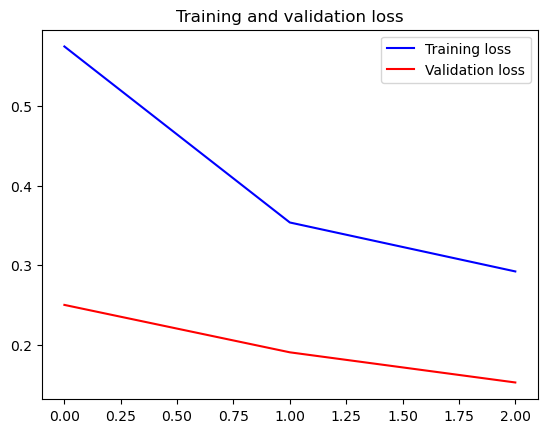

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 112, 112, 32)         0         ['bn_Conv1[0][0]']        

 block_3_expand_relu (ReLU)  (None, 56, 56, 144)          0         ['block_3_expand_BN[0][0]']   
                                                                                                  
 block_3_pad (ZeroPadding2D  (None, 57, 57, 144)          0         ['block_3_expand_relu[0][0]'] 
 )                                                                                                
                                                                                                  
 block_3_depthwise (Depthwi  (None, 28, 28, 144)          1296      ['block_3_pad[0][0]']         
 seConv2D)                                                                                        
                                                                                                  
 block_3_depthwise_BN (Batc  (None, 28, 28, 144)          576       ['block_3_depthwise[0][0]']   
 hNormalization)                                                                                  
          

 block_6_depthwise_BN (Batc  (None, 14, 14, 192)          768       ['block_6_depthwise[0][0]']   
 hNormalization)                                                                                  
                                                                                                  
 block_6_depthwise_relu (Re  (None, 14, 14, 192)          0         ['block_6_depthwise_BN[0][0]']
 LU)                                                                                              
                                                                                                  
 block_6_project (Conv2D)    (None, 14, 14, 64)           12288     ['block_6_depthwise_relu[0][0]
                                                                    ']                            
                                                                                                  
 block_6_project_BN (BatchN  (None, 14, 14, 64)           256       ['block_6_project[0][0]']     
 ormalizat

                                                                                                  
 block_9_add (Add)           (None, 14, 14, 64)           0         ['block_8_add[0][0]',         
                                                                     'block_9_project_BN[0][0]']  
                                                                                                  
 block_10_expand (Conv2D)    (None, 14, 14, 384)          24576     ['block_9_add[0][0]']         
                                                                                                  
 block_10_expand_BN (BatchN  (None, 14, 14, 384)          1536      ['block_10_expand[0][0]']     
 ormalization)                                                                                    
                                                                                                  
 block_10_expand_relu (ReLU  (None, 14, 14, 384)          0         ['block_10_expand_BN[0][0]']  
 )        

                                                                                                  
 block_13_expand_relu (ReLU  (None, 14, 14, 576)          0         ['block_13_expand_BN[0][0]']  
 )                                                                                                
                                                                                                  
 block_13_pad (ZeroPadding2  (None, 15, 15, 576)          0         ['block_13_expand_relu[0][0]']
 D)                                                                                               
                                                                                                  
 block_13_depthwise (Depthw  (None, 7, 7, 576)            5184      ['block_13_pad[0][0]']        
 iseConv2D)                                                                                       
                                                                                                  
 block_13_

 iseConv2D)                                                                                       
                                                                                                  
 block_16_depthwise_BN (Bat  (None, 7, 7, 960)            3840      ['block_16_depthwise[0][0]']  
 chNormalization)                                                                                 
                                                                                                  
 block_16_depthwise_relu (R  (None, 7, 7, 960)            0         ['block_16_depthwise_BN[0][0]'
 eLU)                                                               ]                             
                                                                                                  
 block_16_project (Conv2D)   (None, 7, 7, 320)            307200    ['block_16_depthwise_relu[0][0
                                                                    ]']                           
          

In [1]:
import os
import glob
from keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from keras.preprocessing.image import ImageDataGenerator
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model
from keras.optimizers import SGD
import matplotlib.pyplot as plt

IM_WIDTH, IM_HEIGHT = 224, 224
NB_EPOCHS = 3
BAT_SIZE = 32
FC_SIZE = 128
NB_MNV2_LAYERS_TO_FREEZE = 18  # Adjust this parameter
train_dir = "C:\\DatasetNew\\train"
val_dir = "C:\\DatasetNew\\val"
test_dir = "C:\\DatasetNew\\test"

def get_nb_files(directory):
    count = 0
    for root, dirs, files in os.walk(directory):
        count += len(files)
    return count

def add_new_last_layer_mobilenetv2(base_model, nb_classes, dropout_rate=0.5):
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(FC_SIZE, activation='relu')(x)
    x = Dropout(dropout_rate)(x)  # Add dropout layer
    predictions = Dense(nb_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

def setup_to_transfer_learn_mobilenetv2(model, base_model):
    for layer in base_model.layers:
        layer.trainable = False
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

def setup_to_finetune_mobilenetv2(model):
    for layer in model.layers[:NB_MNV2_LAYERS_TO_FREEZE]:
        layer.trainable = False
    for layer in model.layers[NB_MNV2_LAYERS_TO_FREEZE:]:
        layer.trainable = True
    model.compile(optimizer=SGD(learning_rate=0.0001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(len(acc))

    plt.plot(epochs, acc, 'b', label='Training acc')
    plt.plot(epochs, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

def train_mobilenetv2(train_dir, val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenetv2-ft.model", plot=True):
    nb_train_samples = get_nb_files(train_dir)
    nb_classes = len(glob.glob(train_dir + "/*"))
    nb_val_samples = get_nb_files(val_dir)

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
        # Filling strategy for rotated images
    )

    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=30,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True
    )
    
    train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    validation_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(IM_WIDTH, IM_HEIGHT),
        batch_size=batch_size,
        class_mode='categorical'
    )

    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IM_WIDTH, IM_HEIGHT, 3))
    model = add_new_last_layer_mobilenetv2(base_model, nb_classes)

    setup_to_transfer_learn_mobilenetv2(model, base_model)

    history_tl = model.fit(
        train_generator,
        epochs=nb_epoch,
        steps_per_epoch=nb_train_samples // batch_size,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    setup_to_finetune_mobilenetv2(model)

    history_ft = model.fit(
        train_generator,
        steps_per_epoch=nb_train_samples // batch_size,
        epochs=nb_epoch,
        validation_data=validation_generator,
        validation_steps=nb_val_samples // batch_size,
        
    )

    model.save(output_model_file)

    if plot:
        plot_training(history_ft)

    return model

# Train the MobileNetV2 model and get the trained model
trained_mobilenetv2_model = train_mobilenetv2(train_dir=train_dir, val_dir=val_dir, nb_epoch=NB_EPOCHS, batch_size=BAT_SIZE, output_model_file="mobilenetv2-ft.model", plot=True)

# Display the model summary
trained_mobilenetv2_model.summary()
